In [ ]:
#Jnomics Media - Data Analysis Test - TASK 1: Exploratory & Insights
#by Hanif Maulana Abdullah

#TASK 1.1 Subscription Growth, breakdown by plans and sources (monthly)

In [2]:
#Task 1.1 Growth driven by who?
#using subscriptions csv
#import library and csv
import pandas as pd #for table
pd.set_option('display.expand_frame_repr', False) #to show dataframe in fully horizontal (no wrap)

#upload the csv to gdrive, share link to public:
url_subs="https://drive.google.com/uc?export=download&id=1zOerxqcMLhEChUNOMQQpKLuUThsQZ1I0"
df_subs=pd.read_csv(url_subs) #read csv file as dataFrame
#print(df_subs.head()) #check table as dataFrame

#create filter: we will work only for end_date at min. 1 Apr 2025 or NaN
df_filtered = df_subs[(df_subs['end_date'] >= '2025-04-01') | (df_subs['end_date'].isnull())]
#print(df_filtered)

#define the lists
months = ['2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10',
          '2025-11', '2025-12', '2026-01', '2026-02', '2026-03',] #Apr25 to Mar26
plans = ['monthly', 'annual']
months_subs = [] #list for active subs count in loop
month_plan = [] #list for each plans
annual_plan = []
email_source = [] #list for each sources
organic_source = []
promo_source = []
referral_source = []
social_source = []

#make sure dataframe lists format are datetime, so math operations can work
df_filtered['start_date'] = pd.to_datetime(df_filtered['start_date'])
df_filtered['end_date'] = pd.to_datetime(df_filtered['end_date'])

for i in months: #loop count for active subs from Apr25 to Mar26
  start = pd.to_datetime(i + '-01')
  end = start + pd.offsets.MonthEnd(0)

  df_month = df_filtered[
      (df_filtered['start_date'] <= end) &
      ((df_filtered['end_date'] >= start) | (df_filtered['end_date'].isnull()))
  ] #create monthly cohort, ex: start_date <= 30 Apr & (end_date >= 1 Apr or NaN)

  #counting growth
  count = df_month.shape[0] #count rows of each month
  months_subs.append(count) #add each loop to list

  #counting per plan
  plan_count = df_month.plan.value_counts()
  month_count = plan_count['monthly'] #extract monthly from value_counts
  annual_count = plan_count['annual']
  month_plan.append(month_count) #add to monthly list
  annual_plan.append(annual_count)
  #print(plan_count)

  #counting per source
  source_count = df_month.acquisition_source.value_counts()
  email_count = source_count['email'] #extract email from acquisition_source
  organic_count = source_count['organic']
  promo_count = source_count['promo']
  referral_count = source_count['referral']
  social_count = source_count['social']

  email_source.append(email_count) #add to email list
  organic_source.append(organic_count)
  promo_source.append(promo_count)
  referral_source.append(referral_count)
  social_source.append(social_count)
  #end of loop

#convert "2025-04" to "Apr 25"
months_clear = pd.to_datetime(months).strftime('%b %y')

#dataframe after counting active subs, plans per month
df_months_plan = pd.DataFrame(
    {'month': months_clear, 'active subscriptions': months_subs,
    'monthly plan': month_plan, 'annual plan': annual_plan,})
print(df_months_plan)

#dataframe after counting active subs, sources per month
df_months_source = pd.DataFrame(
    {'month': months_clear, 'active subscriptions': months_subs,
     'email': email_source, 'organic': organic_source, 'promo': promo_source,
     'referral': referral_source, 'social': social_source})
print(df_months_source)

#prepare plotting
#to plot in seaborn Chart 1.1.1
df_plot1 = df_months_plan.melt(
    id_vars='month',
    value_vars=['monthly plan', 'annual plan'],
    var_name='plan',
    value_name='value'
)
#print(df_plot1)

#to plot in seaborn Chart 1.1.2
df_plot2 = df_months_source.melt(
    id_vars='month',
    value_vars=['email', 'organic', 'promo', 'referral', 'social'],
    var_name='source',
    value_name='value'
)
#print(df_plot2)
#end of code

     month  active subscriptions  monthly plan  annual plan
0   Apr 25                   407           216          191
1   May 25                   407           207          200
2   Jun 25                   408           196          212
3   Jul 25                   419           193          226
4   Aug 25                   394           170          224
5   Sep 25                   387           166          221
6   Oct 25                   415           183          232
7   Nov 25                   457           207          250
8   Dec 25                   487           211          276
9   Jan 26                   503           205          298
10  Feb 26                   495           193          302
11  Mar 26                   514           201          313
     month  active subscriptions  email  organic  promo  referral  social
0   Apr 25                   407     65      133     51        65      93
1   May 25                   407     63      124     57        67      9

/tmp/ipykernel_1795/3357445778.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['start_date'] = pd.to_datetime(df_filtered['start_date'])
/tmp/ipykernel_1795/3357445778.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['end_date'] = pd.to_datetime(df_filtered['end_date'])


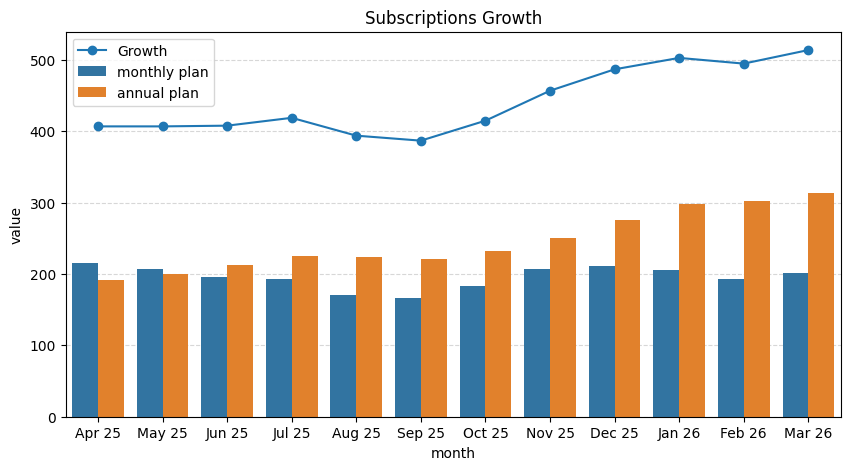

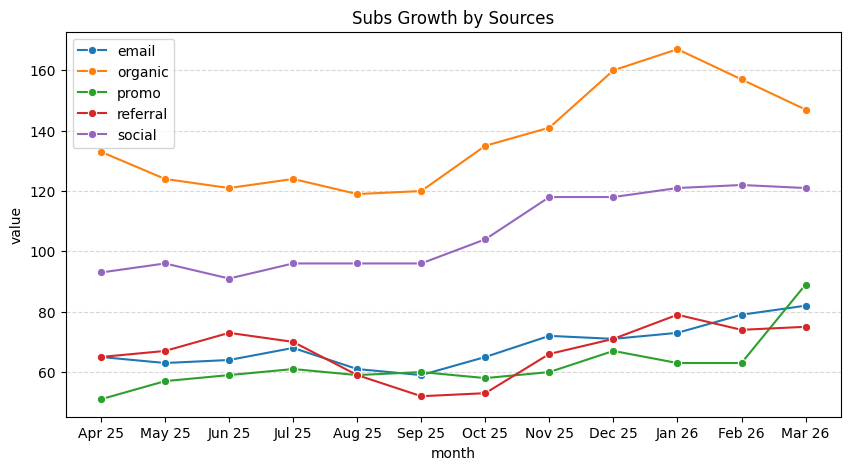

In [5]:
#plotting task 1.1
import matplotlib.pyplot as plt #for plotting
import seaborn as sns

#Chart 1.1.2
plt.figure(figsize=(10, 5))
plt.title("Subscriptions Growth")
#line chart
plt.plot(df_months_plan['month'], df_months_plan['active subscriptions'], marker='o', label='Growth')
#sideby bar chart using seaborn lib
sns.barplot(data=df_plot1, x='month', y='value', hue='plan')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True)
plt.legend()
plt.show()

#Chart 1.1.2
plt.figure(figsize=(10, 5))
plt.title("Subs Growth by Sources")
#multiple line chart using seaborn lib
sns.lineplot(data=df_plot2, x='month', y='value', hue='source', marker='o')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True)
plt.legend()
plt.show()

Subscriber growth is heavily influenced by acquisition sources and periods. Plan types complement each other.

Chart 1.1.1 shows a 25% increase in subscriptions over the course of a year. This aligns with the growth of annual plans, while monthly plans tend to fluctuate over the same period. This suggests that annual plans are gradually becoming a favorite among users.

Chart 1.2.1 shows that organic subscribers dominate each month, followed by social media. Meanwhile, subscribers from promotions, referrals, and email also increased, but experienced fluctuations in the middle. Interestingly, in March 2026, subscribers from promotions suddenly more than doubled and reached a peak of 50. This indicates that the promotional strategy in March 2026 proved successful and should be taken into consideration when developing future strategies.

#TASK 1.2 Paying vs Non-paying Users

In [7]:
#TASK 1.2 Who Subscribes?
#using subscriptions csv
#import library and csv
import pandas as pd #for table
pd.set_option('display.expand_frame_repr', False) #to show dataframe in fully horizontal (no wrap)

#upload the csv to gdrive, share link to public:
url_subs="https://drive.google.com/uc?export=download&id=1zOerxqcMLhEChUNOMQQpKLuUThsQZ1I0"
df_subs=pd.read_csv(url_subs) #read csv file as dataFrame
#print(df_subs.head()) #check table as dataFrame

#trying to find "PAYING user" in this period
#create filter: we will work only for end_date at min. 1 Apr 2025 or NaN
df_filtered = df_subs[(df_subs['end_date'] >= '2025-04-01') | (df_subs['end_date'].isnull())]
#print(df_filtered)

#make sure dataframe lists format are datetime, so math operations can work
df_filtered['end_date'] = pd.to_datetime(df_filtered['end_date'])

#sorting dataframe based on end_date, oldest to newest
df_sorted = df_filtered.sort_values(by='end_date')
#print(df_sorted)

#erase every multiplicated user_id, we only use the newest end_date
df_cleaned = df_sorted.drop_duplicates(subset='user_id', keep='last')
print(df_cleaned)

#take user_id from cleaned dataframe --> they are officially "PAYING" users in this period
paying_users = df_cleaned['user_id']
#print(paying_users)

         sub_id   user_id  start_date   end_date     plan  price_usd acquisition_source
417   s_0000417  u_000916  2024-12-02 2025-04-01  monthly       9.99            organic
493   s_0000493  u_001081  2025-01-02 2025-04-02  monthly       9.99              email
651   s_0000651  u_001399  2025-03-04 2025-04-03  monthly       9.99              promo
654   s_0000654  u_001407  2025-03-04 2025-04-03  monthly       9.99              email
486   s_0000486  u_001044  2025-01-03 2025-04-03  monthly       9.99            organic
...         ...       ...         ...        ...      ...        ...                ...
1398  s_0001398  u_002970  2026-03-30        NaT   annual      99.00              promo
1399  s_0001399  u_002982  2026-03-31        NaT   annual      99.00              promo
1400  s_0001400  u_002983  2026-03-31        NaT   annual      99.00            organic
1401  s_0001401  u_002993  2026-03-28        NaT  monthly       9.99              promo
1402  s_0001402  u_002995  2026-

/tmp/ipykernel_1795/2929328612.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['end_date'] = pd.to_datetime(df_filtered['end_date'])


In [11]:
#insert these PAYING users status to existing users csv file
#using users csv
#import library and csv
import pandas as pd #for table
pd.set_option('display.expand_frame_repr', False) #to show dataframe in fully horizontal (no wrap)

#upload the csv to gdrive, share link to public:
url_users="https://drive.google.com/uc?export=download&id=1Q5JjNWcGq5IatRrsd_VWD8y3bqdn_5N0"
df_users=pd.read_csv(url_users) #read csv file as dataFrame
#print(df_users) #check table as dataFrame

#make new list: "STATUS" (contains of PAYING and NON-PAYING) in users csv dataframe
#PAYING: Users who actively subs anywhere between 1 Apr 25 to 31 Mar 26
#NON-PAYING: Others. Include they who subs but ends before 1 Apr 2025
df_users['status'] = df_users['user_id'].isin(paying_users).map({
    True: 'paying',
    False: 'non-paying'
})
print(df_users)

#groupby before plotting
#groupby status
paying_count = df_users.groupby('status').size()
#print(paying_count)

#groupby before plotting
#groupby status vs (country, device)
status_country = df_users.groupby(['country', 'status']).size() #status vs country
status_device = df_users.groupby(['device', 'status']).size() #status vs device
#status_age = df_users.groupby(['age', 'status']).size() #status vs age
print(status_country)

#--------
#preparation for plotting Chart 1.2.1. Status vs Country
status_country = status_country.reset_index(name='count')
#print(status_country)

#sorting country count from highest to lowest
total_country = status_country.groupby('country')['count'].sum().reset_index(name='count_c') #total count per country
sort_country = total_country.sort_values(by='count_c', ascending=False)['country'] #sorting count from highest to lowest
#print(total_country)
#print(sort_country)

#--------
#preparation for plotting Chart 1.2.2. Status vs Device
status_device = status_device.reset_index(name='count')
#print(status_device)

#convert device count to percentage
total_device = status_device.groupby('device')['count'].sum().reset_index(name='count_d') #total count per device
merge_device = status_device.merge(total_device, on='device') #merge df total_device to status_device
merge_device['percentage'] = round((merge_device['count'] / merge_device['count_d']) * 100, 2) #convert to percentage
#print(total_device)
print(merge_device)

       user_id  country  age gender city_size   device registration_date      status
0     u_000000      USA   48      M     small  desktop        2024-04-01  non-paying
1     u_000001  Ukraine   26      F  regional  desktop        2024-04-01  non-paying
2     u_000002      USA   18      F   capital   mobile        2024-04-01  non-paying
3     u_000003       UK   18      M   capital   mobile        2024-04-01  non-paying
4     u_000004  Ukraine   53      F  regional  desktop        2024-04-01  non-paying
...        ...      ...  ...    ...       ...      ...               ...         ...
2995  u_002995   Poland   43      F   capital  desktop        2026-03-29      paying
2996  u_002996  Germany   38      M   capital   mobile        2026-03-29  non-paying
2997  u_002997  Ukraine   42      M   capital   mobile        2026-03-30  non-paying
2998  u_002998    Other   27      M  regional   mobile        2026-03-31  non-paying
2999  u_002999  Ukraine   33      F     small  desktop        202

In [12]:
#--------
#preparation for plotting Chart 1.2.3. Status vs Age
import pandas as pd

#define age cohort: 15-24, 25-34, 35-44, 45-54, >=55
df_age=df_users.copy()
df_age['age'] = pd.cut(
    df_users['age'],
    bins=[18, 24, 34, 44, 54, 100],
    labels=['18-24', '25-34', '35-44', '45-54', '55+'],
    right=True
)
#print (df_age)

#age_count = df_age['age'].value_counts()
#print(age_count)

#groupby status vs age
status_age = df_age.groupby(['age', 'status']).size()
status_age = status_age.reset_index(name='count')
print(status_age)

     age      status  count
0  18-24  non-paying    197
1  18-24      paying     91
2  25-34  non-paying    551
3  25-34      paying    290
4  35-44  non-paying    652
5  35-44      paying    317
6  45-54  non-paying    310
7  45-54      paying    181
8    55+  non-paying    121
9    55+      paying     63


/tmp/ipykernel_1795/525794862.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  status_age = df_age.groupby(['age', 'status']).size()


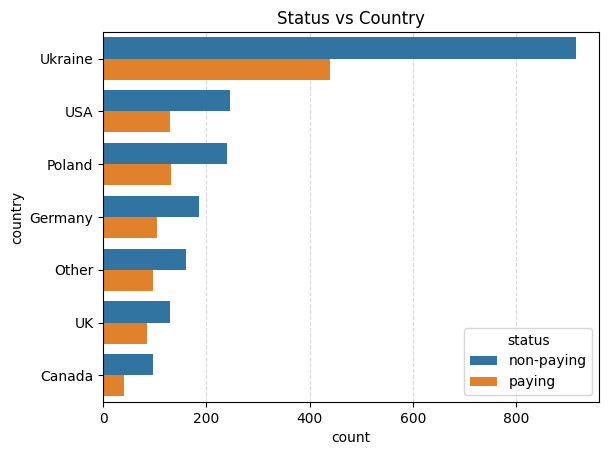

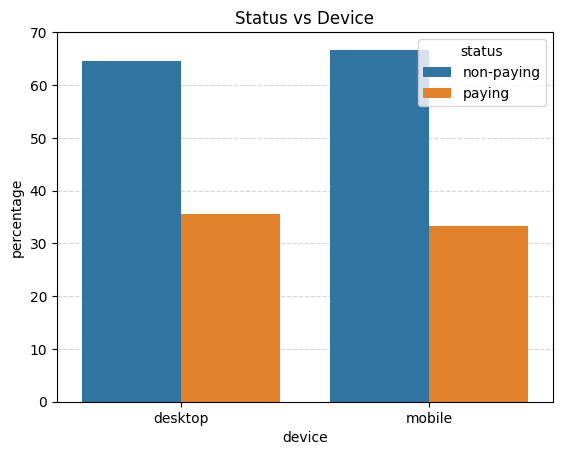

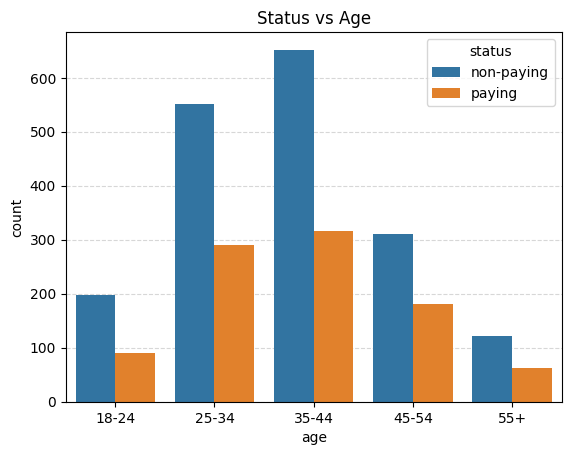

In [14]:
#plotting
import matplotlib.pyplot as plt #for plotting
import seaborn as sns

#Plot 1.2.1.
plt.title("Status vs Country")
sns.barplot(data=status_country, x='count', y='country', hue='status', order=sort_country)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True)
plt.show()

#Plot 1.2.2.
plt.title("Status vs Device")
sns.barplot(data=merge_device, x='device', y='percentage', hue='status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True)
plt.show()

#Plot 1.2.3.
plt.title("Status vs Age")
sns.barplot(data=status_age, x='age', y='count', hue='status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True)
plt.show()

Subscribers are dominated by users in Ukraine aged around 35-44. Device doesn't matter much, as both desktop and mobile charts are nearly identical.

#Task 1.3 Monthly Churn Rate? Vary by monthly cohort or plan type?

In [23]:
#TASK 1.3 Monthly Churn Rate?
#using subscriptions csv
#import library and csv
import pandas as pd #for table
pd.set_option('display.expand_frame_repr', False) #to show dataframe in fully horizontal (no wrap)

#upload the csv to gdrive, share link to public:
url_subs="https://drive.google.com/uc?export=download&id=1zOerxqcMLhEChUNOMQQpKLuUThsQZ1I0"
df_subs=pd.read_csv(url_subs) #read csv file as dataFrame
#print(df_subs.head()) #check table as dataFrame

#create filter: we will work only for end_date at min. 1 Apr 2025 or NaN
df_filtered = df_subs[(df_subs['end_date'] >= '2025-04-01') | (df_subs['end_date'].isnull())]
#print(df_filtered)

#create new list: monthly_ed (end_date become end_month)
df_filtered_add = df_filtered.copy()
df_filtered_add['monthly_ed'] = pd.to_datetime(df_filtered['end_date']).dt.to_period('M')
#df_filtered_add['monthly_ed'] = pd.to_datetime(df_filtered['end_date']).dt.strftime('%b %y')
#print(df_filtered_add)

#define the lists
months = ['2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10',
          '2025-11', '2025-12', '2026-01', '2026-02', '2026-03',] #Apr25 to Mar26
plans = ['monthly', 'annual']
months_subs = [] #list for active subs count in loop
months_churned = [] #list for churned subs count in loop
month_plan = [] #list for each plans
annual_plan = []

#make sure dataframe lists format are datetime, so math operations can work
df_filtered['start_date'] = pd.to_datetime(df_filtered['start_date'])
df_filtered['end_date'] = pd.to_datetime(df_filtered['end_date'])

for i in months: #loop count for active subs from Apr25 to Mar26
  start = pd.to_datetime(i + '-01')
  end = start + pd.offsets.MonthEnd(0)

  df_month = df_filtered[
      (df_filtered['start_date'] <= end) &
      ((df_filtered['end_date'] >= start) | (df_filtered['end_date'].isnull()))
  ] #create monthly cohort, ex: start_date <= 30 Apr & (end_date >= 1 Apr or NaN)

  #counting growth
  count = df_month.shape[0] #count rows of each month
  months_subs.append(count) #add each loop to list

  #counting per plan
  plan_count = df_month.plan.value_counts()
  month_count = plan_count['monthly'] #extract monthly from value_counts
  annual_count = plan_count['annual']
  month_plan.append(month_count) #add to monthly list
  annual_plan.append(annual_count)
  #print(plan_count)
  #end of loop

#convert "2025-04" to "Apr 25"
months_clear = pd.to_datetime(months).strftime('%b %y')
#months_clear2 = pd.to_datetime(df_filtered_add['monthly_ed']).strftime('%b %y')

#counting churned users
churned_users = df_filtered_add.groupby('monthly_ed').size().reset_index(name='churned')
#print(churned_users)

#dataframe: active subs, churned users
months_churned = pd.DataFrame({'month': months_clear, 'active subscriptions': months_subs,
                               'churned users': churned_users.churned})
#print(months_churned)

#counting and add churned ratio (overall) list to existing df
months_churned['churn ratio'] = round((months_churned['churned users'] / months_churned['active subscriptions']) * 100, 2) #convert to percentage
print(months_churned)

#--------
#groupby churn rate: monthly_ed vs plan PREPARATION
#dataframe after counting active subs, plans per month
df_months_plan = pd.DataFrame(
    {'month': months_clear, 'active subscriptions': months_subs,
    'monthly': month_plan, 'annual': annual_plan,})
#print(df_months_plan)

#turn plans per moth into long format
df_mplan_long = df_months_plan.melt(
    id_vars='month',
    value_vars=['monthly', 'annual'],
    var_name='plan',
    value_name='value'
)
#print(df_mplan_long)

#groupby churn rate: monthly_ed vs plan
churned_plan = df_filtered_add.groupby(['monthly_ed', 'plan']).size().reset_index(name='churned')
churned_plan['monthly_ed'] = churned_plan['monthly_ed'].dt.to_timestamp().dt.strftime('%b %y')
churned_plan = churned_plan.rename(columns={'monthly_ed': 'month'})
#print(churned_plan)

#before plotting monthly churn rate
df_churned_plan = churned_plan.merge(df_mplan_long, on=['month', 'plan'], how='left')
#print(df_churned_plan)

#counting and add churned ratio (overall) list to existing df
df_churned_plan['plan churn ratio'] = round((df_churned_plan['churned'] / df_churned_plan['value']) * 100, 2) #convert to percentage
#print(df_churned_plan)

     month  active subscriptions  churned users  churn ratio
0   Apr 25                   407             53        13.02
1   May 25                   407             58        14.25
2   Jun 25                   408             48        11.76
3   Jul 25                   419             52        12.41
4   Aug 25                   394             50        12.69
5   Sep 25                   387             36         9.30
6   Oct 25                   415             39         9.40
7   Nov 25                   457             53        11.60
8   Dec 25                   487             56        11.50
9   Jan 26                   503             55        10.93
10  Feb 26                   495             52        10.51
11  Mar 26                   514             53        10.31


/tmp/ipykernel_1795/3567779846.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['start_date'] = pd.to_datetime(df_filtered['start_date'])
/tmp/ipykernel_1795/3567779846.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['end_date'] = pd.to_datetime(df_filtered['end_date'])


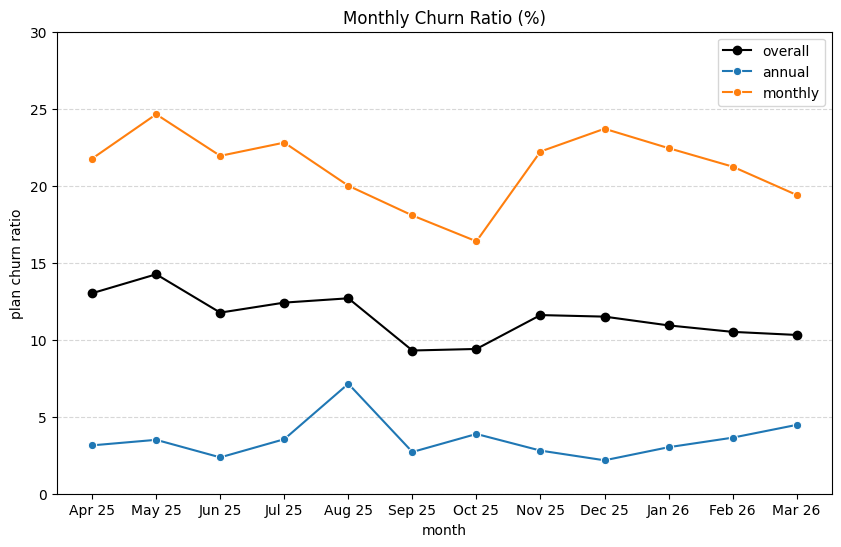

In [18]:
#plotting
import matplotlib.pyplot as plt #for plotting
import seaborn as sns

#Plot 1.3.1
plt.figure(figsize=(10, 6))
plt.title('Monthly Churn Ratio (%)')
#line chart
plt.plot(months_churned['month'], months_churned['churn ratio'], marker='o', label='overall', color='black')
sns.lineplot(data=df_churned_plan, x='month', y='plan churn ratio', hue='plan', marker='o')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 30)
plt.legend()
plt.show()

The monthly churn rate can be seen in the data frame at the top of the chart section. The line chart above shows that the churn ratio is significantly influenced by the monthly cohort and plan type.

#TASK 1.4. Drops and Recoveries

There are drops and recoveries in two different charts: "subscription growth by sources" and "monthly churn ratio."

At the end of the period (around January to March 2026), organic subscribers suddenly experienced a drastic decline. Conversely, in March 2026, promotions suddenly doubled. This was likely influenced by the effectiveness of the promotional strategy in March in response to the decline in subscriptions in February.

Meanwhile, the monthly plan churn ratio experienced a significant decline from July to October 2025, before worsening and rising rapidly in the following two months. Conversely, the annual plan churn ratio worsened, doubling from June to August 2025. The following month, churn recovered. The fluctuations in the churn ratio were likely caused by changes in user quality and experience throughout the period.